# Caffarelli regularity and a non-convex source

This figure illustrates why the convexity assumptions in regularity results for Brenier maps are geometric assumptions, not mere technicalities.  We solve an empirical quadratic optimal transport problem from a non-convex banana-shaped source domain to a disk.  The empirical measures are
\[
\alpha_N = \frac1N \sum_{i=1}^N \delta_{x_i},
\qquad
\beta_N = \frac1N \sum_{j=1}^N \delta_{y_j},
\]
where both point clouds are obtained by farthest-point sampling from dense candidate sets.

The discrete dual potentials satisfy
\[
u_i+v_j \leq \|x_i-y_j\|^2,
\]
and the target potential defines a \(c\)-transform extension away from the sampled source points,
\[
\varphi(z)=\min_j \bigl(\|z-y_j\|^2-v_j\bigr),
\qquad
T(z)=y_{j(z)},
\quad
j(z) \in \arg\min_j \bigl(\|z-y_j\|^2-v_j\bigr).
\]
For the quadratic cost this is the piecewise-constant Laguerre extension of the empirical Brenier map, since formally \(T(z)=z-\nabla\varphi(z)/2\) whenever the minimizer is unique.  A sanity check below verifies that, on every sampled source point, the assigned target is an active minimizer of this c-transform; the deterministic minimizer used for plotting only resolves the remaining finite-dimensional ties.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import ot
from matplotlib.collections import LineCollection
from matplotlib.path import Path as MplPath
from scipy.stats import qmc

root = Path.cwd()
if root.name == "notebooks-figures":
    notebook_dir = root
    sys.path.insert(0, str(root))
else:
    notebook_dir = root / "notebooks-figures"
    sys.path.insert(0, str(notebook_dir))

from figure_style import BLUE, GRAY, LIGHT_GRAY, RED, VIOLET, figure_dir, interp_color, remove_axes, save_pdf, setup_matplotlib

setup_matplotlib()
rng = np.random.default_rng(2034)
OUT = figure_dir("monge-caffarelli-nonconvex-map")

## Banana geometry and farthest-point sampling

The source is a curved tube with variable width, represented by its boundary and by intrinsic coordinates \((s,\eta)\).  Farthest-point sampling gives visually regular empirical measures without imposing a grid.

In [2]:
def rotation_matrix(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])

ROT = rotation_matrix(-0.20)
SCALE = np.array([1.04, 0.97])


def banana_center(s):
    s = np.asarray(s)
    return np.column_stack((1.50 * s, 0.90 * (s**2 - 0.58) + 0.06 * np.sin(1.25 * np.pi * s)))


def banana_width(s):
    s = np.asarray(s)
    taper = np.maximum(1.0 - s**2, 0.0)
    return 0.018 + 0.33 * taper**0.55 * (1.0 + 0.06 * np.cos(np.pi * (s + 0.08)))


def banana_frame(s):
    s = np.asarray(s)
    dc = np.column_stack((np.full_like(s, 1.42), 1.80 * s + 0.075 * np.pi * np.cos(1.25 * np.pi * s)))
    tangent = dc / np.linalg.norm(dc, axis=1, keepdims=True)
    normal = np.column_stack((-tangent[:, 1], tangent[:, 0]))
    return tangent, normal


def transform_points(points):
    return (points @ ROT.T) * SCALE


def banana_point(s, eta):
    s = np.asarray(s)
    eta = np.asarray(eta)
    _, normal = banana_frame(s)
    points = banana_center(s) + (eta * banana_width(s))[:, None] * normal
    return transform_points(points)


def banana_boundary(n=1800):
    s = np.linspace(-1.0, 1.0, n // 2)
    upper = banana_point(s, np.ones_like(s))
    lower = banana_point(s[::-1], -np.ones_like(s))
    return np.vstack((upper, lower))


def banana_candidates(power=17, seed=2035):
    boundary = banana_boundary()
    path = MplPath(boundary)
    lo = boundary.min(axis=0) - 0.04
    hi = boundary.max(axis=0) + 0.04
    sampler = qmc.Sobol(d=2, scramble=True, seed=seed)
    u = sampler.random_base2(power)
    pts = lo + u * (hi - lo)
    return pts[path.contains_points(pts)], boundary


def disk_candidates(power=16, seed=2036):
    sampler = qmc.Sobol(d=2, scramble=True, seed=seed)
    u = sampler.random_base2(power)
    r = np.sqrt(u[:, 0])
    theta = 2 * np.pi * u[:, 1]
    return np.column_stack((r * np.cos(theta), r * np.sin(theta)))


def farthest_point_sample(candidates, n, first="center"):
    candidates = np.asarray(candidates, dtype=float)
    if first == "center":
        center = candidates.mean(axis=0)
        first_idx = np.argmin(np.sum((candidates - center) ** 2, axis=1))
    elif first == "left":
        first_idx = np.argmin(candidates[:, 0])
    else:
        first_idx = int(first)

    selected = np.empty(n, dtype=int)
    selected[0] = first_idx
    dist2 = np.sum((candidates - candidates[first_idx]) ** 2, axis=1)
    for k in range(1, n):
        idx = int(np.argmax(dist2))
        selected[k] = idx
        dist2 = np.minimum(dist2, np.sum((candidates - candidates[idx]) ** 2, axis=1))
    return candidates[selected]


N = 2400
banana_pool, BOUNDARY = banana_candidates(power=17)
disk_pool = disk_candidates(power=16)
X = farthest_point_sample(banana_pool, N, first="center")
Y = farthest_point_sample(disk_pool, N, first="center")

print(f"banana candidates: {len(banana_pool):,}; disk candidates: {len(disk_pool):,}; samples per measure: {N:,}")

banana candidates: 48,606; disk candidates: 65,536; samples per measure: 2,400


## Discrete transport and dual c-transform

We solve the balanced empirical problem with uniform weights.  The target dual potential returned by the network simplex gives the Laguerre cells used to extend the map to every point of the banana.

In [3]:
a = np.full(N, 1.0 / N)
b = np.full(N, 1.0 / N)
C = np.sum((X[:, None, :] - Y[None, :, :]) ** 2, axis=2)

P, log = ot.emd(a, b, C, log=True, numItermax=10_000_000)
assigned = np.argmax(P, axis=1)

target_potential = np.asarray(log["v"], dtype=float)

# POT returns a valid dual pair.  The target potential defines the c-transform
# extension.  Because the dual solution is not unique, many sampled points sit on
# tied Laguerre boundaries; the correct sanity check is that the assigned target
# belongs to the c-transform argmin set.
def ctransform_scores(points, target_potential=target_potential, chunk=512):
    scores = []
    for start in range(0, len(points), chunk):
        Z = points[start : start + chunk]
        scores.append(np.sum((Z[:, None, :] - Y[None, :, :]) ** 2, axis=2) - target_potential[None, :])
    return np.vstack(scores)


def ctransform_labels(points, target_potential=target_potential, chunk=512):
    labels = []
    for start in range(0, len(points), chunk):
        Z = points[start : start + chunk]
        scores = np.sum((Z[:, None, :] - Y[None, :, :]) ** 2, axis=2) - target_potential[None, :]
        labels.append(np.argmin(scores, axis=1))
    return np.concatenate(labels)

sample_scores = ctransform_scores(X)
assigned_scores = sample_scores[np.arange(N), assigned]
best_scores = sample_scores.min(axis=1)
assignment_gap = assigned_scores - best_scores
raw_argmin_labels = np.argmin(sample_scores, axis=1)
raw_argmin_rate = np.mean(raw_argmin_labels == assigned)
argmin_set_rate = np.mean(assignment_gap <= 1e-9)

row_error = np.max(np.abs(P.sum(axis=1) - a))
col_error = np.max(np.abs(P.sum(axis=0) - b))
duality_gap = np.sum(P * C) - (np.dot(a, log["u"]) + np.dot(b, log["v"]))

print(f"assigned target in c-transform argmin set: {100 * argmin_set_rate:.2f}%")
print(f"raw deterministic argmin agreement before tie-breaking: {100 * raw_argmin_rate:.2f}%")
print(f"largest assigned-edge c-transform gap: {assignment_gap.max():.2e}")
print(f"max marginal errors: rows={row_error:.2e}, columns={col_error:.2e}")
print(f"duality gap with POT convention: {duality_gap:.2e}")
assert argmin_set_rate == 1.0
assert assignment_gap.max() < 1e-9


def transport_map(points, chunk=512):
    return Y[ctransform_labels(np.asarray(points), target_potential, chunk=chunk)]

assigned target in c-transform argmin set: 100.00%
raw deterministic argmin agreement before tie-breaking: 48.46%
largest assigned-edge c-transform gap: 3.60e-12
max marginal errors: rows=0.00e+00, columns=0.00e+00
duality gap with POT convention: -2.78e-16


## Level curves and their images

The curves are drawn in intrinsic banana coordinates.  Their images are obtained by evaluating the same c-transform map, not by interpolating the discrete assignment directly.

In [4]:
def level_curves():
    curves = []
    s_grid = np.linspace(-0.985, 0.985, 880)
    etas = np.array([-0.82, -0.58, -0.34, -0.12, 0.12, 0.34, 0.58, 0.82])
    for eta in etas:
        pts = banana_point(s_grid, np.full_like(s_grid, eta))
        color = interp_color((eta - etas.min()) / (etas.max() - etas.min()), RED, BLUE)
        curves.append({"points": pts, "color": color, "lw": 0.78, "kind": "longitudinal"})

    eta_grid = np.linspace(-0.92, 0.92, 420)
    s_values = np.linspace(-0.78, 0.78, 7)
    for s0 in s_values:
        pts = banana_point(np.full_like(eta_grid, s0), eta_grid)
        color = interp_color((s0 - s_values.min()) / (s_values.max() - s_values.min()), RED, BLUE)
        curves.append({"points": pts, "color": color, "lw": 0.50, "kind": "transversal"})
    return curves

CURVES = level_curves()
IMAGE_CURVES = [{**curve, "points": transport_map(curve["points"])} for curve in CURVES]

## Rendering

The panels contain no embedded title; LaTeX provides the title and caption.  The mapped curves are drawn as small points and only very short connected pieces because the c-transform extension is piecewise constant across Laguerre cells.

In [5]:
def set_limits_from(points, ax, pad=0.08):
    lo = points.min(axis=0)
    hi = points.max(axis=0)
    center = 0.5 * (lo + hi)
    radius = 0.5 * max(hi - lo) * (1 + pad)
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)




def set_tight_limits_from(points, ax, pad=0.055):
    lo = points.min(axis=0)
    hi = points.max(axis=0)
    span = hi - lo
    lo = lo - pad * span
    hi = hi + pad * span
    ax.set_xlim(lo[0], hi[0])
    ax.set_ylim(lo[1], hi[1])
    ax.set_aspect("equal", adjustable="box")


def draw_banana(ax):
    ax.fill(BOUNDARY[:, 0], BOUNDARY[:, 1], color=(0.985, 0.985, 0.985), zorder=0)
    ax.plot(np.r_[BOUNDARY[:, 0], BOUNDARY[0, 0]], np.r_[BOUNDARY[:, 1], BOUNDARY[0, 1]], color=(0.12, 0.12, 0.12), lw=0.95, zorder=3)
    for curve in CURVES:
        pts = curve["points"]
        ax.plot(pts[:, 0], pts[:, 1], color=curve["color"], lw=curve["lw"], alpha=0.92, solid_capstyle="round")
    set_tight_limits_from(BOUNDARY, ax, pad=0.055)
    remove_axes(ax)


def draw_mapped_curve(ax, pts, color, lw, threshold=0.050):
    if len(pts) < 2:
        return
    distances = np.linalg.norm(np.diff(pts, axis=0), axis=1)
    mask = distances < threshold
    if np.any(mask):
        segs = np.stack((pts[:-1][mask], pts[1:][mask]), axis=1)
        ax.add_collection(LineCollection(segs, colors=[color], linewidths=0.40 * lw, alpha=0.28, zorder=2))
    ax.scatter(pts[:, 0], pts[:, 1], s=1.05, marker="o", color=color, alpha=0.84, linewidths=0, zorder=3, rasterized=True)


def draw_disk_image(ax):
    theta = np.linspace(0, 2 * np.pi, 900)
    disk = np.column_stack((np.cos(theta), np.sin(theta)))
    ax.fill(disk[:, 0], disk[:, 1], color=(0.985, 0.985, 0.985), zorder=0)
    ax.plot(disk[:, 0], disk[:, 1], color=(0.12, 0.12, 0.12), lw=0.95, zorder=4)
    for curve in IMAGE_CURVES:
        draw_mapped_curve(ax, curve["points"], curve["color"], curve["lw"])
    ax.set_xlim(-1.08, 1.08)
    ax.set_ylim(-1.08, 1.08)
    ax.set_aspect("equal", adjustable="box")
    remove_axes(ax)


fig, ax = plt.subplots(figsize=(3.75, 1.65))
draw_banana(ax)
save_pdf(fig, OUT / "source-circles.pdf")
plt.close(fig)

fig, ax = plt.subplots(figsize=(2.95, 2.95))
draw_disk_image(ax)
save_pdf(fig, OUT / "bean-image-circles.pdf")
plt.close(fig)

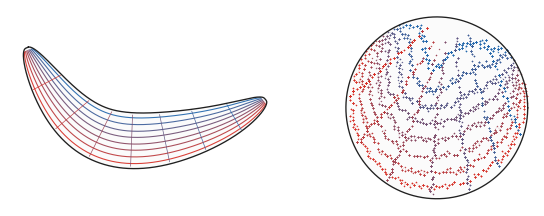

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(7.25, 2.55))
draw_banana(axes[0])
draw_disk_image(axes[1])
fig.subplots_adjust(wspace=0.08)
thumbnail_path = notebook_dir / "thumbnails" / "monge-caffarelli-nonconvex-map.png"
thumbnail_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(thumbnail_path, dpi=220, bbox_inches="tight", pad_inches=0.02)
plt.show()